In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import skimage

In [3]:
pheno_triax = np.load('./data/pheno_triax.npy')
dislo_triax = np.load('./data/dislo_triax.npy')

In [95]:
material_IDs = np.load("polycrystal_128_VE_material_IDs.npy")

(-2.5632673672083546, 4.400635413902881)

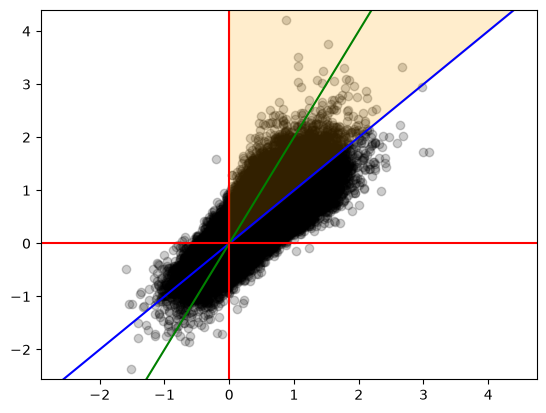

In [36]:
plt.scatter(pheno_triax.flatten(), dislo_triax.flatten(), color = 'k', alpha = 0.2)
min_val = min(min(pheno_triax.flatten()), min(dislo_triax.flatten()))
max_val = max(max(pheno_triax.flatten()), max(dislo_triax.flatten()))

interval = np.linspace(0, max_val + 0.2, 1000)
plt.axline((min_val - 0.2, min_val - 0.2), (max_val + 0.2, max_val + 0.2), color = 'b')
plt.axline((0,0), slope = 2, color = "g")
plt.axhline(0, -2.5, max_val, color = "r")
plt.axvline(0, -2.5, max_val, color = "r")

plt.fill_between(interval, interval, 5, color = "orange", alpha = 0.2)
plt.ylim(min_val - 0.2, max_val + 0.2)

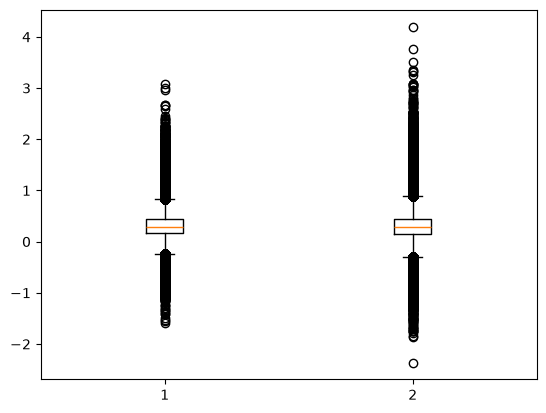

In [59]:
# Box plot
boxplot = plt.boxplot((pheno_triax.flatten(), dislo_triax.flatten()))
pheno_fliers = [val for val in boxplot["fliers"][0].get_ydata()]
dislo_fliers = [val for val in boxplot["fliers"][1].get_ydata()]

Comparing similarity

In [93]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error

nrmse_triax_pheno_norm = np.sqrt(np.mean((pheno_triax - dislo_triax)**2))/np.mean(np.abs(pheno_triax))
nrmse_triax_dislo_norm = np.sqrt(np.mean((pheno_triax - dislo_triax)**2))/np.mean(np.abs(dislo_triax))
ssim_score_triax = ssim(pheno_triax, dislo_triax, data_range = max_val - min_val)
corr_coeff_triax = np.corrcoef(pheno_triax.ravel(), dislo_triax.ravel())[0,1]
mean_err = np.abs(np.mean(pheno_triax.flatten()) - np.mean(dislo_triax.flatten()))/(np.mean(pheno_triax.flatten()))
nrmse_triax_pheno_norm, nrmse_triax_dislo_norm, ssim_score_triax, corr_coeff_triax, mean_err

(np.float64(0.48145723781877064),
 np.float64(0.4747788462649059),
 np.float64(0.787622918432155),
 np.float64(0.7986890862925127),
 np.float64(0.01193421737388615))

In [103]:
# Grain-averaged triaxiality

grain_averaged_pheno_triax_vals = []
grain_averaged_dislo_triax_vals = []
for i in range(0,1000):
    material_IDs_grain = np.where(material_IDs.flatten()== i)
    grain_dislo_triax_vals = []
    grain_pheno_triax_vals = []
    for j in range(len(material_IDs_grain)):
        grain_dislo_triax_vals.append(pheno_triax.flatten()[material_IDs_grain[j]])
        grain_pheno_triax_vals.append(dislo_triax.flatten()[material_IDs_grain[j]])

    grain_averaged_dislo_triax_vals.append(np.mean(grain_dislo_triax_vals))
    grain_averaged_pheno_triax_vals.append(np.mean(grain_pheno_triax_vals))

In [118]:
grain_averaged_dislo_triax_vals, grain_averaged_pheno_triax_vals

nrmse_triax_pheno_norm = np.sqrt(np.mean((np.array(grain_averaged_pheno_triax_vals) - np.array(grain_averaged_dislo_triax_vals))**2))/np.mean(np.abs(np.array(grain_averaged_pheno_triax_vals)))
nrmse_triax_dislo_norm = np.sqrt(np.mean((np.array(grain_averaged_pheno_triax_vals )- np.array(grain_averaged_dislo_triax_vals))**2))/np.mean(np.abs(np.array(grain_averaged_dislo_triax_vals)))
ssim_score_grain_avg_triax = ssim(np.array(grain_averaged_pheno_triax_vals), np.array(grain_averaged_dislo_triax_vals), data_range = max(max(grain_averaged_dislo_triax_vals), max(grain_averaged_pheno_triax_vals)) - min(min(grain_averaged_dislo_triax_vals), min(grain_averaged_pheno_triax_vals)))
corr_coeff_grain_avg_triax = np.corrcoef(grain_averaged_pheno_triax_vals, grain_averaged_dislo_triax_vals)[0,1]
mean_err_grain_avg_triax = np.abs(np.mean(grain_averaged_pheno_triax_vals) - np.mean(grain_averaged_dislo_triax_vals))/(np.mean(grain_averaged_pheno_triax_vals))
nrmse_triax_pheno_norm, nrmse_triax_dislo_norm, ssim_score_grain_avg_triax, corr_coeff_grain_avg_triax, mean_err_grain_avg_triax

(np.float64(0.059746137017503434),
 np.float64(0.05896809069979039),
 np.float64(0.9844286666812045),
 np.float64(0.9885829144803956),
 np.float64(0.013520020384476241))

Extracting values where DD CP predicts larger triaxiality than phenopowerlaw CP

In [40]:
# First find all values where both DD and phenopowerlaw CP predict stress triaxiality > 0
pheno_roi = pheno_triax.flatten()
dislo_roi = dislo_triax.flatten()
for i in range(len(pheno_roi)):
    if not (dislo_roi[i] > 0 and pheno_roi[i] > 0 and dislo_roi[i] > pheno_roi[i]):
        pheno_roi[i] = np.nan
        dislo_roi[i] = np.nan

In [ ]:
pheno_roi_vals = [val for val in pheno_roi if not np.isnan(val)]
dislo_roi_vals = [val for val in dislo_roi if not np.isnan(val)]
print(len(pheno_roi_vals)/128**3)

0.43743276596069336


In [65]:
pheno_roi_cube = pheno_roi.reshape([128,128,128])
dislo_roi_cube = dislo_roi.reshape([128,128,128])

In [66]:
# Phenopowerlaw
pheno_roi_grid = pv.ImageData()
pheno_roi_grid.dimensions = (pheno_roi_cube.shape[0]+1, pheno_roi_cube.shape[1]+1, pheno_roi_cube.shape[2]+1)
pheno_roi_grid.spacing = (1.0e-3/pheno_roi_cube.shape[0], 1.0e-3/pheno_roi_cube.shape[1], 1.0e-3/pheno_roi_cube.shape[2])
pheno_roi_grid.cell_data["triax_values"] = pheno_roi_cube.flatten(order = 'F')

pheno_roi_grid.save("pheno_128_triax_roi.vti")

In [67]:
# Dislotwin
dislo_roi_grid = pv.ImageData()
dislo_roi_grid.dimensions = (dislo_roi_cube.shape[0]+1, dislo_roi_cube.shape[1]+1, dislo_roi_cube.shape[2]+1)
dislo_roi_grid.spacing = (1.0e-3/dislo_roi_cube.shape[0], 1.0e-3/dislo_roi_cube.shape[1], 1.0e-3/dislo_roi_cube.shape[2])
dislo_roi_grid.cell_data["triax_values"] = dislo_roi_cube.flatten(order = 'F')

dislo_roi_grid.save("dislo_128_triax_roi.vti")

Finding index and grain of highest triaxiality voxels

In [68]:
pheno_triax_max_idx = np.where(pheno_triax.flatten() == max(pheno_triax.flatten()))[0]
print(pheno_triax_max_idx)

[368298]


In [70]:
pheno_triax.flatten()[368298], dislo_triax.flatten()[368298]

(np.float64(3.079690866754879), np.float64(1.7221744315946255))

In [82]:
dislo_triax_max_idx = np.where(dislo_triax.flatten()==max(dislo_triax.flatten()))[0]
print(dislo_triax_max_idx)

[1379524]


In [71]:
dislo_triax.flatten()[1379524], pheno_triax.flatten()[1379524]

(np.float64(4.200635413902881), np.float64(0.8832390363923561))

In [143]:
material_IDs.flatten()[pheno_triax_max_idx], material_IDs.flatten()[dislo_triax_max_idx + 16384]

(array([62]), array([763]))

In [ ]:
pheno_triax_grid = pv.ImageData()
dislo_triax_grid = pv.ImageData()

pheno_triax_grid.dimensions = (pheno_triax.shape[0]+1, pheno_triax.shape[1]+1, pheno_triax.shape[2]+1)
dislo_triax_grid.dimensions = (dislo_triax.shape[0]+1, dislo_triax.shape[1]+1, dislo_triax.shape[2]+1)

pheno_triax_grid.cell_data["triax_values"] = pheno_triax.flatten(order = 'F')
dislo_triax_grid.cell_data["triax_values"] = dislo_triax.flatten(order = 'F')

Full triaxiality from each model

In [64]:
pheno_triax.shape[2]+1

129

In [65]:
# Phenopowerlaw
pheno_full_triax_grid = pv.ImageData()
pheno_full_triax_grid.dimensions = (pheno_triax.shape[0]+1, pheno_triax.shape[1]+1, pheno_triax.shape[2]+1)
pheno_full_triax_grid.spacing = (1.0e-3/pheno_triax.shape[0], 1.0e-3/pheno_triax.shape[1], 1.0e-3/pheno_triax.shape[2])
pheno_full_triax_grid.cell_data["triax_values"] = pheno_triax.flatten(order = 'F')

pheno_full_triax_grid.save("pheno_128_triax.vti")

In [67]:
# Dislotwin
dislo_full_triax_grid = pv.ImageData()
dislo_full_triax_grid.dimensions = (dislo_triax.shape[0]+1, dislo_triax.shape[1]+1, dislo_triax.shape[2]+1)
dislo_full_triax_grid.spacing = (1.0e-3/dislo_triax.shape[0], 1.0e-3/dislo_triax.shape[1], 1.0e-3/dislo_triax.shape[2])
dislo_full_triax_grid.cell_data["triax_values"] = dislo_triax.flatten(order = 'F')

dislo_full_triax_grid.save("dislo_128_triax.vti")

Original attempt at extracting regions where largest differences are observed between the two CP models

In [3]:
dislo_triax_flat = dislo_triax.flatten()
pheno_triax_flat = pheno_triax.flatten()
print(dislo_triax_flat.max(), pheno_triax_flat.max(), dislo_triax.min(), pheno_triax_flat.min())

for i in range(len(pheno_triax_flat)):
    if (dislo_triax_flat[i] > 0 and pheno_triax_flat[i] > 0) or (dislo_triax_flat[i] < 0 and pheno_triax_flat[i] < 0) :
        pheno_triax_flat[i] = np.nan
        dislo_triax_flat[i] = np.nan



triax_largest_diff_flat = np.empty(len(pheno_triax_flat))
triax_largest_diff_flat[:] = np.nan

for i in range(len(pheno_triax_flat)):
    if not np.isnan(pheno_triax_flat[i]):
        if pheno_triax_flat[i] > 0:
            triax_largest_diff_flat[i] = pheno_triax_flat[i] - dislo_triax_flat[i]
        elif dislo_triax_flat[i] > 0:
            triax_largest_diff_flat[i] = dislo_triax_flat[i] - pheno_triax_flat[i]
print(triax_largest_diff_flat)

4.200635413902881 3.079690866754879 -2.3632673672083544 -1.5881929104520698
[nan nan nan ... nan nan nan]


Tensile stress triaxialities

In [23]:
pheno_tensile_triax_flat = pheno_triax.flatten()
dislo_tensile_triax_flat = dislo_triax.flatten()

for i in range(len(pheno_tensile_triax_flat)):
    if not (dislo_tensile_triax_flat[i] > 0 and pheno_tensile_triax_flat[i] > 0):
        pheno_tensile_triax_flat[i] = np.nan
        dislo_tensile_triax_flat[i] = np.nan

triax_tensile_diff = dislo_tensile_triax_flat - pheno_tensile_triax_flat

print(triax_tensile_diff)
#triax_tensile_diff = np.empty(len(pheno_tensile_triax_flat))
#triax_tensile_diff[:] = np.nan

#for i in range(len(pheno_tensile_triax_flat)):
#    if not np.isnan(pheno_tensile_triax_flat[i]):

[ 0.09052726 -0.04006935  0.05073204 ...  0.17755789 -0.07122117
  0.13253217]


In [24]:
triax_tensile_diff = triax_tensile_diff.reshape([128,128,128])

In [52]:
triax_tensile_grid = pv.ImageData()
triax_tensile_grid.dimensions = (triax_tensile_diff.shape[0]+1, triax_tensile_diff.shape[1]+1, triax_tensile_diff.shape[2]+1)
triax_tensile_grid.spacing = (1.0e-3/(triax_tensile_diff.shape[0]), 1.0e-3/(triax_tensile_diff.shape[1]), 1.0e-3/(triax_tensile_diff.shape[2]))
triax_tensile_grid.cell_data["triax_values"] = triax_tensile_diff.flatten(order = 'F')

triax_tensile_grid.save("triax_tensile_diff.vti")

In [33]:
triax_tensile_diff_dislo_larger = [val for val in triax_tensile_diff.flatten() if val > 0]
triax_tensile_diff_pheno_larger = [val for val in triax_tensile_diff.flatten() if val < 0]

print(len(triax_tensile_diff_dislo_larger), len(triax_tensile_diff_pheno_larger))
(len(triax_tensile_diff_dislo_larger) + len(triax_tensile_diff_pheno_larger))/len(triax_tensile_diff.flatten())

917363 934828


0.8831934928894043

Compressive stress triaxialities

In [39]:
pheno_compress_triax_flat = pheno_triax.flatten()
dislo_compress_triax_flat = dislo_triax.flatten()

for i in range(len(pheno_compress_triax_flat)):
    if not (dislo_compress_triax_flat[i] < 0 and pheno_compress_triax_flat[i] < 0):
        pheno_compress_triax_flat[i] = np.nan
        dislo_compress_triax_flat[i] = np.nan

triax_compress_diff = np.abs(dislo_compress_triax_flat) - np.abs(pheno_compress_triax_flat)

In [40]:
triax_compress_diff = triax_compress_diff.reshape([128,128,128])

In [53]:
triax_compress_grid = pv.ImageData()
triax_compress_grid.dimensions = (triax_compress_diff.shape[0]+1, triax_compress_diff.shape[1]+1, triax_compress_diff.shape[2]+1)
triax_compress_grid.spacing = (1.0e-3/(triax_compress_diff.shape[0]), 1.0e-3/(triax_compress_diff.shape[1]), 1.0e-3/(triax_compress_diff.shape[2]))
triax_compress_grid.cell_data["triax_values"] = triax_compress_diff.flatten(order = 'F')

triax_compress_grid.save("triax_compress_diff.vti")

In [42]:
triax_compress_diff_dislo_larger = [val for val in triax_compress_diff.flatten() if val > 0]
triax_compress_diff_pheno_larger = [val for val in triax_compress_diff.flatten() if val < 0]

print(len(triax_compress_diff_dislo_larger), len(triax_compress_diff_pheno_larger))
(len(triax_compress_diff_dislo_larger) + len(triax_compress_diff_pheno_larger))/len(triax_compress_diff.flatten())

59347 37116


0.04599714279174805

Tensile phenopowerlaw and compressive dislotwin

In [ ]:
pheno_tensile_triax_opp_flat = pheno_triax.flatten()
dislo_compress_triax_opp_flat = dislo_triax.flatten()

for i in range(len(pheno_tensile_triax_opp_flat)):
    if not (dislo_compress_triax_opp_flat[i] < 0 and pheno_tensile_triax_opp_flat[i] > 0):
        pheno_tensile_triax_opp_flat[i] = np.nan
        dislo_compress_triax_opp_flat[i] = np.nan

triax_pheno_tens_dislo_comp_diff = pheno_tensile_triax_opp_flat - dislo_compress_triax_opp_flat

In [54]:
triax_pheno_tens_dislo_comp_diff = triax_pheno_tens_dislo_comp_diff.reshape([128,128,128])

triax_pheno_tens_dislo_comp_diff_grid = pv.ImageData()
triax_pheno_tens_dislo_comp_diff_grid.dimensions = (triax_pheno_tens_dislo_comp_diff.shape[0]+1, triax_pheno_tens_dislo_comp_diff.shape[1]+1, triax_pheno_tens_dislo_comp_diff.shape[2]+1)
triax_pheno_tens_dislo_comp_diff_grid.spacing = (1.0e-3/(triax_pheno_tens_dislo_comp_diff.shape[0]), 1.0e-3/(triax_pheno_tens_dislo_comp_diff.shape[1]), 1.0e-3/(triax_pheno_tens_dislo_comp_diff.shape[2]))
triax_pheno_tens_dislo_comp_diff_grid.cell_data["triax_values"] = triax_pheno_tens_dislo_comp_diff.flatten(order = 'F')

triax_pheno_tens_dislo_comp_diff_grid.save("triax_pheno_tensile_dislo_compress_diff.vti")

In [51]:
triax_pheno_tens_dislo_comp_not_nan = [val for val in triax_pheno_tens_dislo_comp_diff.flatten() if not np.isnan(val)]

len(triax_pheno_tens_dislo_comp_not_nan)/128**3

0.04739809036254883

Tensile dislotwin and compressive phenopowerlaw

In [45]:
pheno_compress_triax_opp_flat = pheno_triax.flatten()
dislo_tensile_triax_opp_flat = dislo_triax.flatten()

for i in range(len(pheno_compress_triax_opp_flat)):
    if not (dislo_tensile_triax_opp_flat[i] > 0 and pheno_compress_triax_opp_flat[i] < 0):
        pheno_compress_triax_opp_flat[i] = np.nan
        dislo_tensile_triax_opp_flat[i] = np.nan

triax_dislo_tens_pheno_comp_diff = dislo_tensile_triax_opp_flat - pheno_compress_triax_opp_flat

In [55]:
triax_dislo_tens_pheno_comp_diff = triax_dislo_tens_pheno_comp_diff.reshape([128,128,128])

triax_dislo_tens_pheno_comp_diff_grid = pv.ImageData()
triax_dislo_tens_pheno_comp_diff_grid.dimensions = (triax_dislo_tens_pheno_comp_diff.shape[0]+1, triax_dislo_tens_pheno_comp_diff.shape[1]+1, triax_dislo_tens_pheno_comp_diff.shape[2]+1)
triax_dislo_tens_pheno_comp_diff_grid.spacing = (1.0e-3/(triax_dislo_tens_pheno_comp_diff.shape[0]), 1.0e-3/(triax_dislo_tens_pheno_comp_diff.shape[1]), 1.0e-3/(triax_dislo_tens_pheno_comp_diff.shape[2]))
triax_dislo_tens_pheno_comp_diff_grid.cell_data["triax_values"] = triax_dislo_tens_pheno_comp_diff.flatten(order = 'F')

triax_dislo_tens_pheno_comp_diff_grid.save("triax_dislo_tensile_pheno_compress_diff.vti")

In [50]:
triax_dislo_tens_pheno_comp_not_nan = [val for val in triax_dislo_tens_pheno_comp_diff.flatten() if not np.isnan(val)]
len(triax_dislo_tens_pheno_comp_not_nan)/128**3

0.023411273956298828

Original extraction of regions where the triaxiality differs in sign between the two models

In [ ]:
triax_largest_diff_flat_no_nans = []
for i in range(len(triax_largest_diff_flat)):
    if not np.isnan(triax_largest_diff_flat[i]):
        triax_largest_diff_flat_no_nans.append(triax_largest_diff_flat[i])

In [ ]:
triax_largest_diff_flat_no_nans_threshold = [val for val in triax_largest_diff_flat_no_nans if val > 0.1]
len(triax_largest_diff_flat_no_nans_threshold)/len(triax_largest_diff_flat_no_nans)

In [ ]:
max(triax_largest_diff_flat_no_nans), min(triax_largest_diff_flat_no_nans)

In [ ]:
triax_largest_diff_opp = triax_largest_diff_flat.reshape([128,128,128])

In [ ]:
triax_largest_diffs_grid = pv.ImageData()
triax_largest_diffs_grid.dimensions = (triax_largest_diff_opp.shape[0]+1, triax_largest_diff_opp.shape[1]+1, triax_largest_diff_opp.shape[2]+1)
triax_largest_diffs_grid.cell_data["triax_values"] = triax_largest_diff_opp.flatten(order = 'F')

triax_largest_diffs_grid.save("triax_comp_grid_abs_diff.vti")

triax_largest_diffs_grid_no_nan = triax_largest_diffs_grid.threshold([-np.inf, np.inf], scalars="triax_values")

triax_diff_pl = pv.Plotter()
triax_diff_pl.add_volume(
    triax_largest_diffs_grid_no_nan,
    scalars = 'triax_values',
    cmap = 'cool',
    opacity = 'linear',
    scalar_bar_args={"title": r"Triaxiality, T"})

triax_diff_pl.show()

In [ ]:
triax_largest_diffs_grid_no_nan.n_cells/triax_largest_diffs_grid.n_cells